In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Customer_Segmentation.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (113036, 18)

Column Names:
['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender', 'Country', 'State', 'Product_Category', 'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Revenue']

Data Types:
Date                object
Day                  int64
Month               object
Year                 int64
Customer_Age         int64
Age_Group           object
Customer_Gender     object
Country             object
State               object
Product_Category    object
Sub_Category        object
Product             object
Order_Quantity       int64
Unit_Cost            int64
Unit_Price           int64
Profit               int64
Cost                 int64
Revenue              int64
dtype: object

Missing Values:
Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26/11/2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26/11/2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23/03/2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23/03/2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15/05/2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [ ]:
# Descriptive statistics for numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns

stats = df[numeric_columns].agg(
    ['mean', 'median', 'std', 'min', 'max']
).T

stats

,mean,median,std,min,max
Day,15.665753,16.0,8.781567,1.0,31.0
Year,2014.401739,2014.0,1.272510,2011.0,2016.0
Customer_Age,35.919212,35.0,11.021936,17.0,87.0
Order_Quantity,11.901660,10.0,9.561857,1.0,32.0
Unit_Cost,267.296366,9.0,549.835483,1.0,2171.0
Unit_Price,452.938427,24.0,922.071219,2.0,3578.0
Profit,285.051665,101.0,453.887443,-30.0,15096.0
Cost,469.318695,108.0,884.866118,1.0,42978.0
Revenue,754.370360,223.0,1309.094674,2.0,58074.0


In [ ]:
# Mode of numerical columns

mode_values = df[numeric_columns].mode().iloc[0]

mode_values

,0
Day,24.0
Year,2014.0
Customer_Age,31.0
Order_Quantity,1.0
Unit_Cost,2.0
Unit_Price,5.0
Profit,3.0
Cost,1252.0
Revenue,35.0


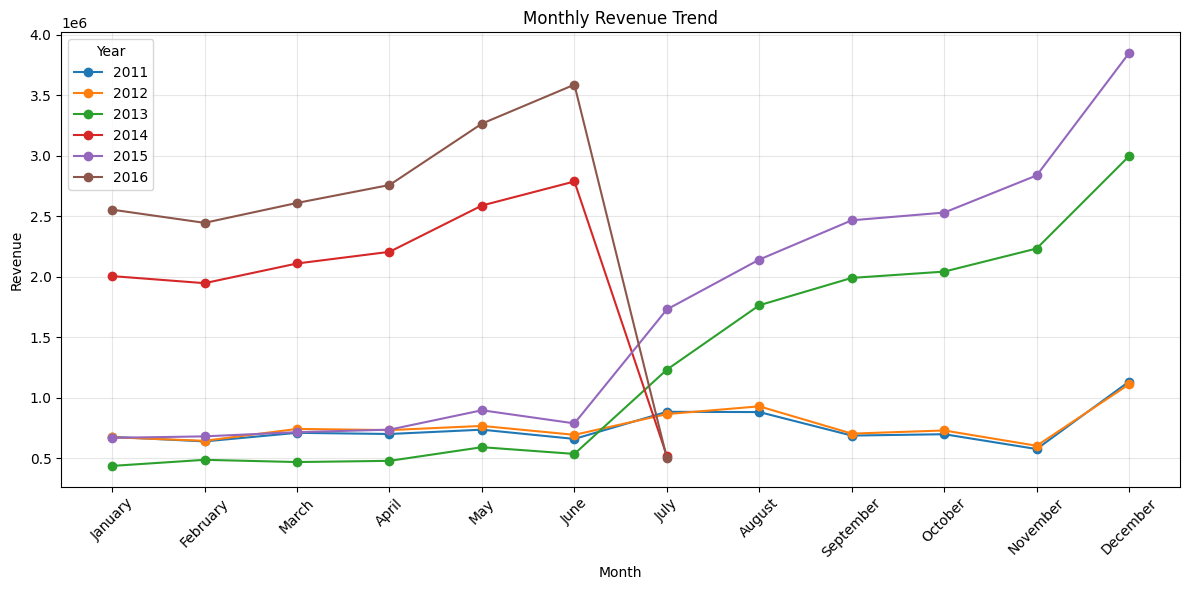

In [ ]:
# Monthly revenue trend

monthly_sales = (
    df.groupby(['Year', 'Month'])['Revenue']
      .sum()
      .reset_index()
)

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values(['Year', 'Month'])

plt.figure(figsize=(12, 6))

for year in monthly_sales['Year'].unique():
    year_data = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(
        year_data['Month'],
        year_data['Revenue'],
        marker='o',
        label=str(year)
    )

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
### Observation – Monthly Revenue Trend

### The monthly revenue trend shows noticeable variation across years and months. Revenue is generally higher in the later years, with 2015 and 2016 showing stronger sales performance compared with the earlier years. December records a particularly high revenue level in the years where data is available. Some years contain only partial-year observations, so comparisons for those years should be interpreted carefully.

In [ ]:
# Create a quarter column from the month
quarter_map = {
    'January': 'Q1',
    'February': 'Q1',
    'March': 'Q1',
    'April': 'Q2',
    'May': 'Q2',
    'June': 'Q2',
    'July': 'Q3',
    'August': 'Q3',
    'September': 'Q3',
    'October': 'Q4',
    'November': 'Q4',
    'December': 'Q4'
}

df['Quarter'] = df['Month'].map(quarter_map)

df[['Month', 'Quarter']].head()

,Month,Quarter
0,November,Q4
1,November,Q4
2,March,Q1
3,March,Q1
4,May,Q2


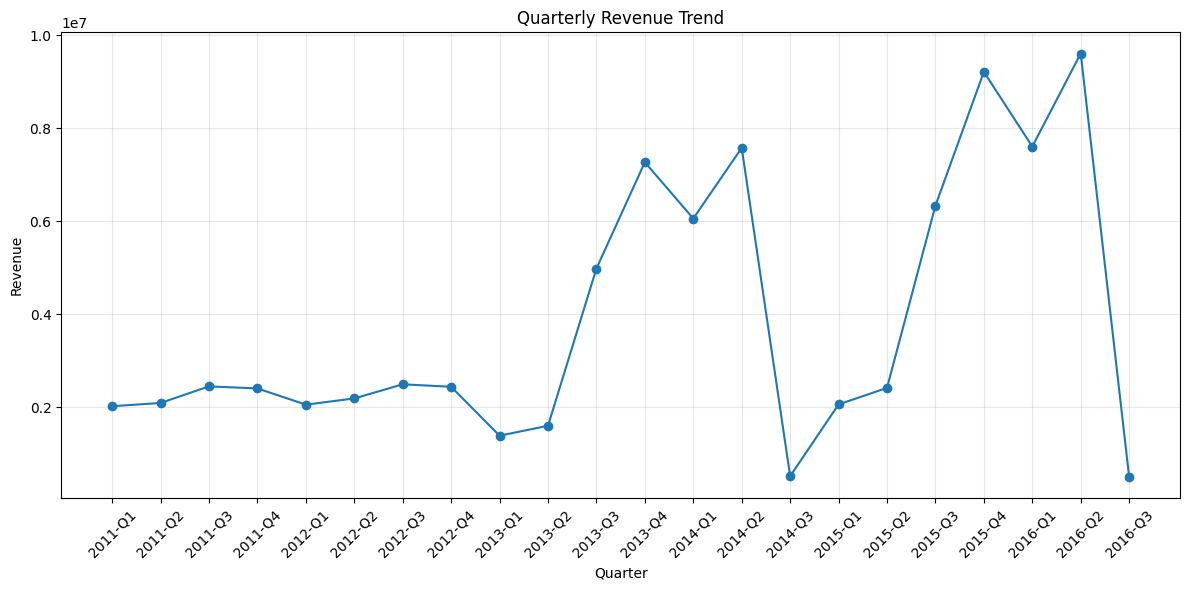

In [ ]:
# Quarterly revenue trend

quarterly_sales = (
    df.groupby(['Year', 'Quarter'])['Revenue']
      .sum()
      .reset_index()
)

quarterly_sales['Quarter_Label'] = (
    quarterly_sales['Year'].astype(str) + '-' +
    quarterly_sales['Quarter']
)

plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_sales['Quarter_Label'],
    quarterly_sales['Revenue'],
    marker='o'
)

plt.title('Quarterly Revenue Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
### Observation – Quarterly Revenue Trend

### Quarterly revenue shows substantial fluctuations across the years.

### Revenue remains relatively low during the earlier periods but increases significantly in the later years.

### The highest quarterly revenue is observed around Q2 of 2016.

### Q3 periods show noticeable declines in several years, indicating possible seasonal variation.

### Overall, the trend suggests improving business performance over time with strong quarterly fluctuations.

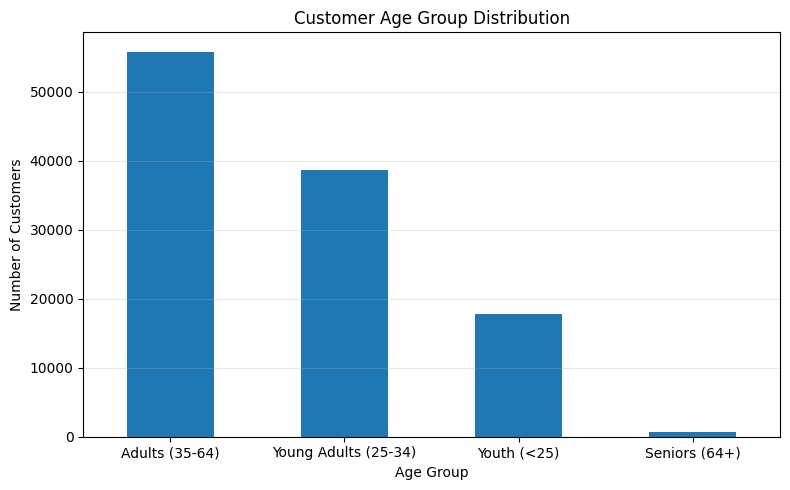

In [ ]:
# Customer age group distribution

age_group_counts = df['Age_Group'].value_counts()

plt.figure(figsize=(8, 5))

age_group_counts.plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
### Observation – Customer Age Group Distribution

### The customer base is dominated by Adults aged 35–64, followed by Young Adults aged 25–34. Youth customers represent a smaller share, while Seniors aged 64+ form the smallest segment. This indicates that the business should focus its core marketing efforts on the 25–64 age range while developing targeted campaigns to increase engagement among younger and senior customers.

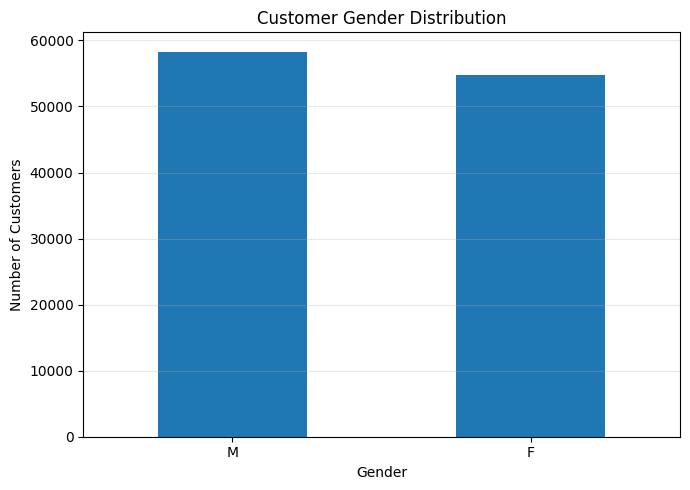

In [ ]:
# Customer gender distribution

gender_counts = df['Customer_Gender'].value_counts()

plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
### Observation – Customer Gender Distribution

### The gender distribution is relatively balanced, although male customers represent a slightly larger share than female customers. The small difference suggests that the business has a broad appeal across genders. Marketing campaigns should therefore maintain broad targeting rather than relying heavily on gender-specific strategies.

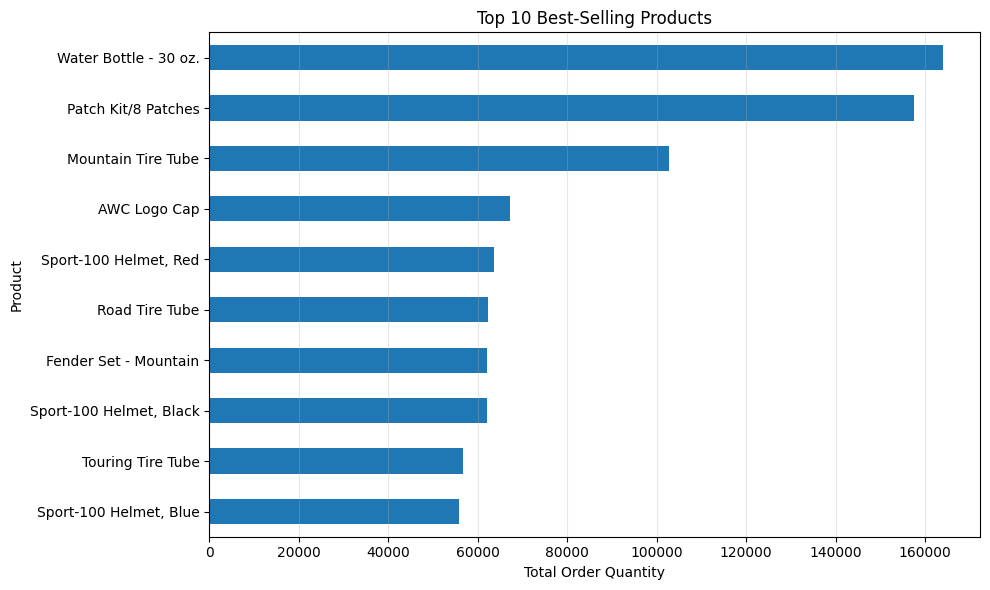

In [ ]:
# Top 10 best-selling products by quantity sold

top_products = (
    df.groupby('Product')['Order_Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Order Quantity')
plt.ylabel('Product')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
### Observation – Top 10 Best-Selling Products

### The Water Bottle - 30 oz. is the clear volume leader, followed by the Patch Kit/8 Patches and Mountain Tire Tube. The top-selling products are mainly practical cycling accessories and maintenance-related items, suggesting strong demand for frequently used and utility-focused products. The business should ensure adequate inventory for these high-volume products to avoid stockouts.

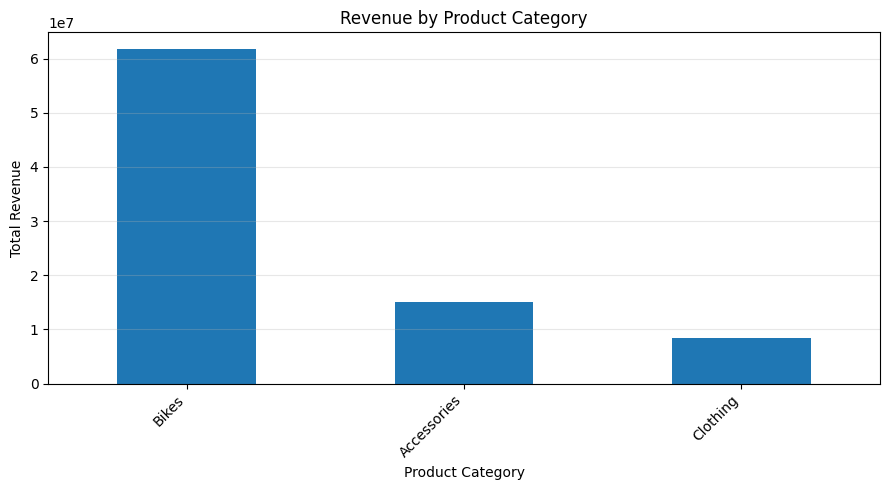

In [ ]:
# Revenue by product category

category_revenue = (
    df.groupby('Product_Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
### Observation — Revenue by Product Category

### Bikes generate the highest total revenue by a substantial margin, followed by Accessories and Clothing. This indicates that Bikes are the primary revenue driver, while Accessories and Clothing contribute smaller portions of overall revenue. The business should continue supporting the strong demand for Bikes while exploring opportunities to increase sales of Accessories and Clothing.

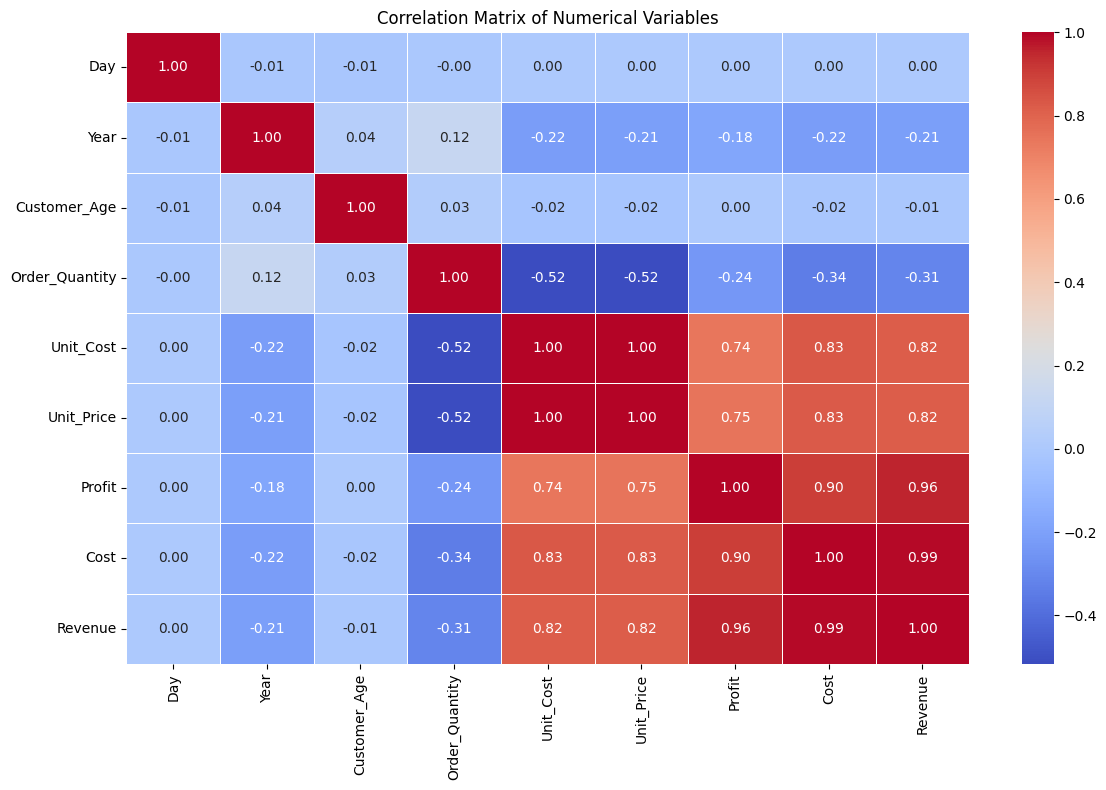

In [ ]:
# Heatmap - Correlation Matrix of Numerical Variables

import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

In [ ]:
### Observation — Correlation Heatmap

### The heatmap shows very strong positive relationships between Revenue, Cost, and Profit, with Revenue strongly correlated with Cost (0.99) and Profit (0.96). Unit Cost and Unit Price are also almost perfectly correlated (1.00). Order Quantity has a moderate negative relationship with Unit Cost and Unit Price (-0.52), suggesting that higher-priced items tend to have lower order quantities.

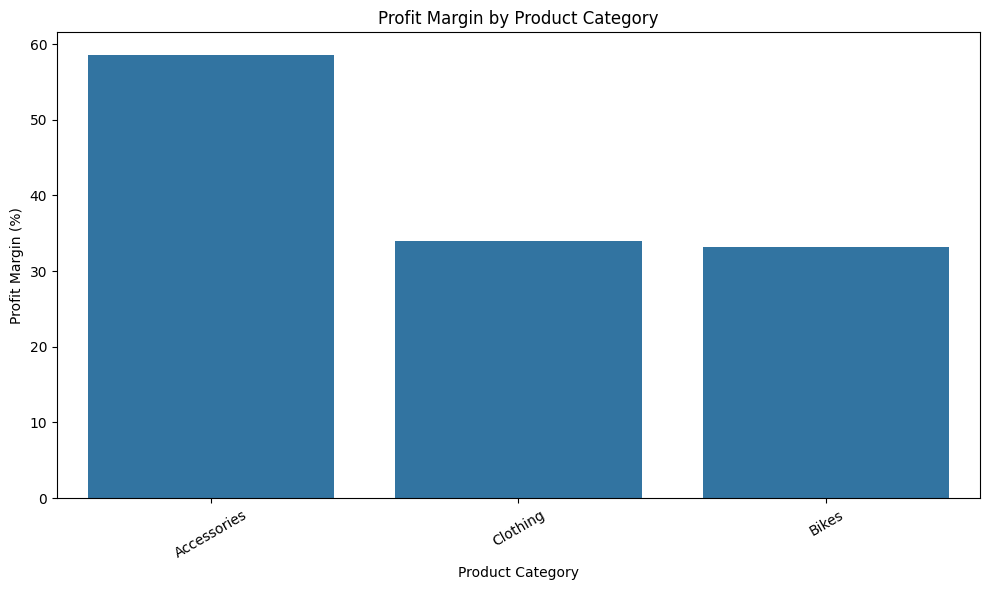

,Product_Category,Total_Revenue,Total_Profit,Profit_Margin_%
0,Accessories,15117992,8862377,58.621390
2,Clothing,8370882,2839447,33.920524
1,Bikes,61782134,20519276,33.212313


In [ ]:
# Additional Visualization - Profit Margin by Product Category

# Calculate profit margin
category_profit = df.groupby('Product_Category').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

category_profit['Profit_Margin_%'] = (
    category_profit['Total_Profit'] /
    category_profit['Total_Revenue']
) * 100

# Sort by profit margin
category_profit = category_profit.sort_values(
    'Profit_Margin_%',
    ascending=False
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_profit,
    x='Product_Category',
    y='Profit_Margin_%'
)

plt.title('Profit Margin by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Display values
category_profit

In [ ]:
### Observation — Profit Margin by Product Category

### Accessories have the highest profit margin at approximately 58.6%, substantially higher than Clothing at 33.9% and Bikes at 33.2%. Although Bikes generate the most revenue, Accessories are considerably more profitable relative to their revenue. This suggests that the business should focus on promoting high-margin Accessories alongside its strong Bike sales.

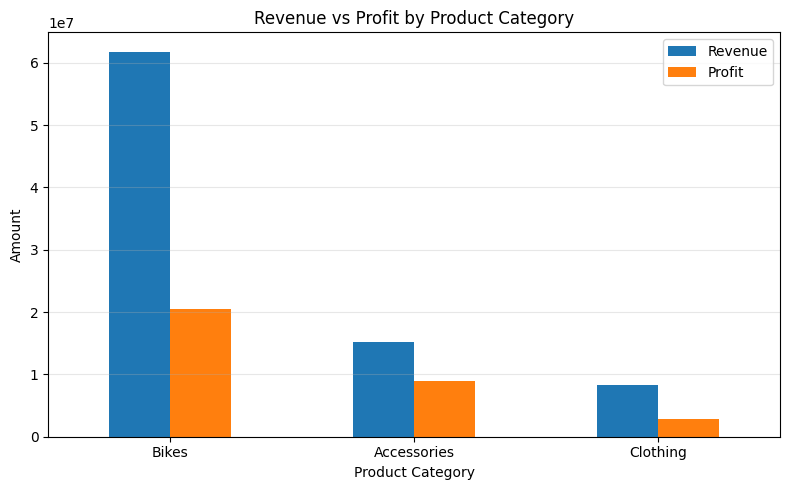

In [ ]:
# Additional visualization - Revenue vs Profit by Product Category

category_summary = (
    df.groupby('Product_Category')[['Revenue', 'Profit']]
    .sum()
    .sort_values('Revenue', ascending=False)
)

category_summary.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Revenue vs Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
### Observation — Revenue vs Profit by Product Category

### Bikes generate the highest revenue and total profit, making them the strongest overall contributor to business earnings. However, Accessories produce a much higher profit relative to their revenue, consistent with their superior profit margin. This suggests that Bikes drive sales volume, while Accessories provide stronger profitability efficiency.

In [ ]:
### CONCLUSION AND BUSINESS RECOMMENDATIONS

### KEY FINDINGS

### 1. Bikes are the primary revenue driver.
### Bikes generate the highest total revenue and profit, making them the
### most important category for overall business performance.

### 2. Accessories have the highest profit margin.
### Accessories achieve a profit margin of approximately 58.6%, compared
### with 33.9% for Clothing and 33.2% for Bikes.

### 3. Adults and young adults form the core customer base.
### Customers aged 35-64 represent the largest customer group, followed
### by customers aged 25-34. Seniors represent a relatively small share
### of customers.

### 4. Sales fluctuate over time.
### Monthly and quarterly sales show noticeable variations, with stronger
### performance observed during later years of the dataset.

### 5. A few products dominate sales volume.
### Water Bottle - 30 oz., Patch Kit/8 Patches, and Mountain Tire Tube
### are among the highest-selling products by order quantity.


### ACTIONABLE BUSINESS RECOMMENDATIONS

### 1. Prioritize Bike inventory.
### Maintain sufficient stock of Bike products because they are the
### largest contributors to revenue and profit.

### 2. Promote high-margin Accessories.
### Expand the Accessories range and use cross-selling or bundle offers
### with Bikes to take advantage of their higher profit margin.

### 3. Target the core customer segments.
### Focus marketing campaigns and loyalty programs on customers aged
### 25-64, particularly the 35-64 group.

### 4. Optimize inventory using product demand.
### Closely monitor high-volume products such as Water Bottle - 30 oz.
### and Patch Kit/8 Patches to reduce the risk of stockouts.

### 5. Use seasonal patterns for planning.
### Use historical monthly and quarterly sales trends to plan inventory,
### promotions, and staffing during periods of higher expected demand.


### OVERALL CONCLUSION

### The analysis shows that business performance is driven by a combination
### of high-volume Bike sales and high-margin Accessories.

### The business can improve profitability by maintaining strong Bike
### availability, expanding high-margin Accessories, targeting core customer
### segments, and using historical sales patterns to improve inventory and
### marketing decisions.